# `01 — Algorithm Complexity Basic`s`
## Topics
- Complexity and asymptotic notation (O, Ω, Θ)
- Worst-case complexity
- Amortized complexity
- Dynamic array / Vector append: worst-case vs amortized (formal proof)

## What I should be able to answer orally
1) Define: algorithm A: X→Y, input size s(x), number of operations t(A,x)
2) Define worst-case complexity T(A,N) = max_{s(x)=N} t(A,x)
3) Explain Big-O and what it means in practice
4) Explain amortized complexity (vs worst-case) and prove amortized O(1) push_back for vector

---

## `1. Complexity model`

An algorithm is a function:
* A: X → Y

- t(A, x): number of elementary operations when executing A on input x
- s(x): size of input x

### `Worst-case complexity`

*T(A, N) = max_{x ∈ X, s(x)=N} t(A, x)


`Interpretation`: Among all inputs of size N, how slow can the algorithm be?

---

## `2. Asymptotic notation`

### `Big-O (upper bound)`
* f(N) ∈ O(g(N)) if there exist constants C > 0 and N0 such that:
for all N ≥ N0:  f(N) ≤ C · g(N)

**Meaning**: f does not grow faster than g up to a constant factor (for large N).


### `Big-Ω (lower bound)`
* f(N) ∈ Ω(g(N)) if ∃ C>0, N0: for all N≥N0: f(N) ≥ C·g(N)


### `Big-Θ (tight bound)`
* f(N) ∈ Θ(g(N)) if f ∈ O(g) and f ∈ Ω(g)

---

## `3. Examples`:


### `Example A`: sum of N integers

* Algorithm: one loop adding items.
* Worst-case: O(N)



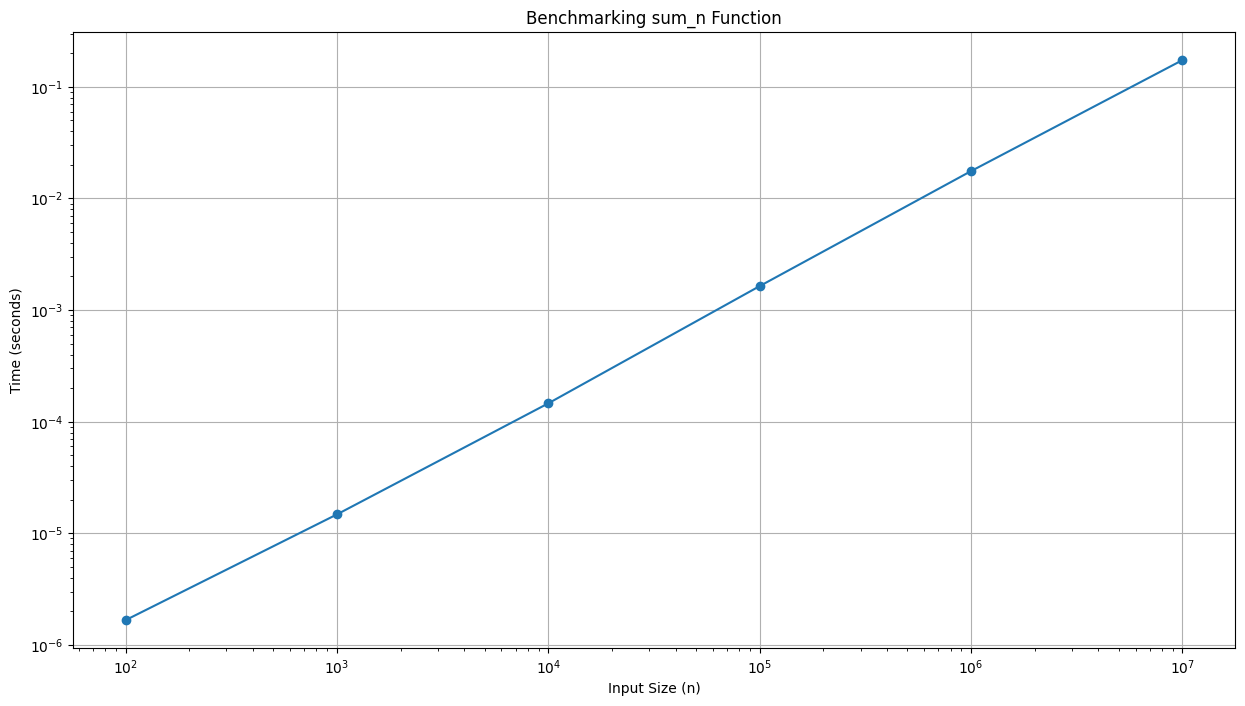

In [1]:

from time import time
from typing import List
import matplotlib.pyplot as plt

def sum_n(nums: List[int]) -> int:
    res: int = 0
    for x in nums:
        res += x
    return res

BATCHE_SIZWE = [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]
TIMINGS = []
for size in BATCHE_SIZWE:
    data = list(range(size))
    start = time()
    sum_n(data)
    end = time()
    TIMINGS.append(end - start)


plt.figure(figsize=(15, 8))
plt.plot(BATCHE_SIZWE, TIMINGS, marker='o')
plt.xscale('log'); plt.yscale('log')
plt.title('Benchmarking sum_n Function'); plt.xlabel('Input Size (n)'); plt.ylabel('Time (seconds)')
plt.grid(True); plt.show()





### `Example B`: check if there exists an equal pair (naive)
Two nested loops over all pairs.
Worst-case: O(N^2)


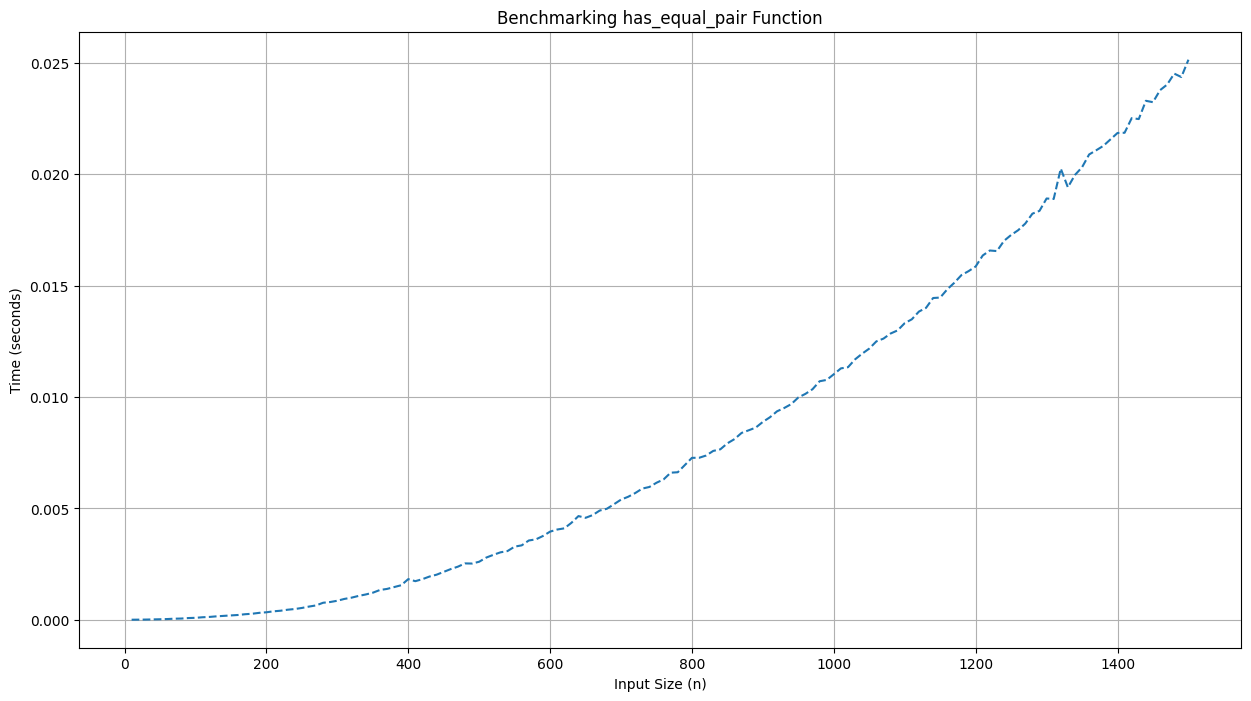

In [1]:
from time import time
from typing import List
import matplotlib.pyplot as plt

def has_equal_pair(nums: List[int]) -> bool:
    n: int = len(nums)
    for i in range(n):
        for j in range(i + 1, n):
            if nums[i] == nums[j]:
                return True
    return False

BATCHE_SIZWE = [i for i in range(10, 1501, 10)]
TIMINGS = []

for size in BATCHE_SIZWE:
    data = list(range(size))
    start = time()
    has_equal_pair(data)
    end = time()
    TIMINGS.append(end - start)
    
plt.figure(figsize=(15, 8))
plt.plot(BATCHE_SIZWE, TIMINGS, linestyle='--')

plt.title('Benchmarking has_equal_pair Function'); plt.xlabel('Input Size (n)');plt.ylabel('Time (seconds)')
plt.grid(True); plt.show()


## `4. Worst-case vs Amortized complexity`

`Worst-case`:
- bound on the cost of ONE operation / run, for the input (or moment) that makes it maximal.

`Amortized`:
- average cost per operation over a WHOLE SEQUENCE of operations,
  without assuming any probability distribution.

`Key point`:

An operation may be occasionally expensive, but the total cost over many operations
can still be small per operation on average.

Formally (sequence of m operations):
Amortized cost = (total actual cost over the sequence) / m

---

## `5. Vector / Dynamic Array: append is worst-case O(N), amortized O(1)`

### ` 5.1 Dynamic Array (Vector) model`

We store elements in a contiguous array of capacity C.
- size = n  (number of stored elements)
- capacity = C (allocated slots)

Operation: push_back(x)
- If n < C: put x in a[n], increment n (cost ~ 1)
- If n == C: allocate new array of size 2C, copy C elements, then insert x
  - copying cost ~ C, total cost ~ C + 1

So:
- Worst-case push_back = O(n) (when resize happens)
- Claim: amortized push_back = O(1) if we double capacity


### `5.2 Proof (Aggregate method): total cost of m appends is O(m)`

Assume:
- start capacity = 1
- when full, we resize by doubling: C → 2C
- cost model:
  - normal insert costs 1
  - resize from C to 2C costs C (copy C elements) + 1 (insert new)

Consider performing m push_back operations starting from empty.

Resizes happen when size reaches:
1, 2, 4, 8, ..., 2^k  (powers of two)

Copy costs across all resizes:
1 + 2 + 4 + ... + 2^k  <  2^(k+1)

But 2^k ≤ m < 2^(k+1), so:
1 + 2 + ... + 2^k  <  2m

Total cost:
- m inserts (each cost 1) → m
- total copying cost < 2m

So total < 3m  ⇒ amortized cost < 3 = O(1)

### `Case A: n < C (no resize)`

Actual cost = 1
n increases by 1, C stays.

ΔΦ = (2(n+1) - C) - (2n - C) = 2

So ĉ = 1 + 2 = 3

### `Case B: n = C (resize)

**Before**: n = C
We allocate new capacity 2C and copy C elements, then insert:
Actual cost = C (copy) + 1 (insert)

**Potential before**:
> Φ_before = 2n - C = 2C - C = C

**After**:
> n' = C + 1
> C' = 2C
> Φ_after = 2(C+1) - 2C = 2
> ΔΦ = 2 - C

Amortized:
ĉ = (C + 1) + (2 - C) = 3

> `Conclusion`: In both cases, ĉ = 3. Therefore, push_back has amortized O(1) complexity.


In [4]:
from typing import List, Tuple

def simulate_dynamic_array_appends(m: int) -> List[Tuple[int, int, int]]:
    """
    Returns a list of (n, capacity, cost) after each append.
    Cost model:
      - cost = 1 for normal append
      - if resize: cost = old_capacity (copy) + 1
    """
    n: int = 0
    capacity: int = 1
    timeline: List[Tuple[int, int, int]] = []

    for _ in range(m):
        if n < capacity:
            cost: int = 1
            n += 1
        else:
            old_capacity: int = capacity
            capacity = 2 * capacity
            cost = old_capacity + 1
            n += 1
        timeline.append((n, capacity, cost))
    return timeline

timeline = simulate_dynamic_array_appends(m=20)
timeline[:10], timeline[-5:]


([(1, 1, 1),
  (2, 2, 2),
  (3, 4, 3),
  (4, 4, 1),
  (5, 8, 5),
  (6, 8, 1),
  (7, 8, 1),
  (8, 8, 1),
  (9, 16, 9),
  (10, 16, 1)],
 [(16, 16, 1), (17, 32, 17), (18, 32, 1), (19, 32, 1), (20, 32, 1)])

## `Big-O Complexity Classes (fastest → slowest)`

For large n, this is the typical growth order (ignoring constant factors and lower-order terms).

---

### `Complexity Hierarchy`

1. **O(1)** — constant
2. **O(log n)** — logarithmic
3. **O(√n)** — sublinear (optional but common)
4. **O(n)** — linear
5. **O(n log n)** — linearithmic
6. **O(n²)** — quadratic
7. **O(n³)** — cubic
8. **O(n^k)** — polynomial (general)
9. **O(c^n)** — exponential (e.g., 2^n)
10. **O(n!)** — factorial
11. **O(n^n)** — "super" exponential (rare in practice, but worst of the bunch)

---

### `Quick Examples per Class`

| Complexity | Example Operations |
|------------|-------------------|
| **O(1)** | Access `a[i]`, push/pop at end of array (no resize), hash lookup average |
| **O(log n)** | Binary search in sorted array; operations on balanced BST |
| **O(√n)** | Trial division up to √n (primality check) |
| **O(n)** | Scan array, sum, find max |
| **O(n log n)** | Sorting; divide-and-conquer mergesort/heapsort; many "efficient" algorithms |
| **O(n²)** | All pairs comparison; naive duplicate check; simple DP tables |
| **O(n³)** | Naive matrix multiplication; Floyd–Warshall |
| **O(2^n)** | Enumerate all subsets (bitmask) |
| **O(n!)** | Enumerate all permutations (TSP brute force) |

---
